In [208]:
import pandas as pd
import numpy as np

In [209]:
data=pd.read_csv(r"C:\Users\vrish\Downloads\health_activity_data.csv")

In [210]:
data.head(4)

,ID,Age,Gender,Height_cm,Weight_kg,BMI,Daily_Steps,Calories_Intake,Hours_of_Sleep,Heart_Rate,Blood_Pressure,Exercise_Hours_per_Week,Smoker,Alcohol_Consumption_per_Week,Diabetic,Heart_Disease
0,1,56,Male,164,81,30.72,5134,1796,8.6,102,137/72,8.1,No,7,No,No
1,2,69,Male,156,82,20.86,12803,1650,4.5,103,129/65,3.7,No,7,No,No
2,3,46,Female,158,65,30.93,16408,1756,4.3,74,127/68,3.2,Yes,0,No,No
3,4,32,Male,197,87,31.19,18420,2359,4.1,116,125/86,8.5,No,5,No,No


In [211]:
data.tail()

,ID,Age,Gender,Height_cm,Weight_kg,BMI,Daily_Steps,Calories_Intake,Hours_of_Sleep,Heart_Rate,Blood_Pressure,Exercise_Hours_per_Week,Smoker,Alcohol_Consumption_per_Week,Diabetic,Heart_Disease
995,996,18,Male,179,116,31.67,10095,2667,4.6,79,108/63,6.3,No,5,No,No
996,997,35,Female,170,114,23.88,11361,2351,7.2,54,98/75,2.9,No,3,No,Yes
997,998,49,Female,169,85,23.44,9531,2416,4.5,80,125/65,7.6,No,4,No,No
998,999,64,Male,155,74,22.34,5270,2080,5.8,101,129/86,5.4,No,4,No,No
999,1000,66,Female,171,86,20.64,10906,1284,8.5,72,118/83,1.3,No,1,No,No


In [212]:
data.isnull().sum

<bound method DataFrame.sum of         ID    Age  Gender  Height_cm  Weight_kg    BMI  Daily_Steps  \
0    False  False   False      False      False  False        False   
1    False  False   False      False      False  False        False   
2    False  False   False      False      False  False        False   
3    False  False   False      False      False  False        False   
4    False  False   False      False      False  False        False   
..     ...    ...     ...        ...        ...    ...          ...   
995  False  False   False      False      False  False        False   
996  False  False   False      False      False  False        False   
997  False  False   False      False      False  False        False   
998  False  False   False      False      False  False        False   
999  False  False   False      False      False  False        False   

     Calories_Intake  Hours_of_Sleep  Heart_Rate  Blood_Pressure  \
0              False           False       False

In [213]:
data.dropna

<bound method DataFrame.dropna of        ID  Age  Gender  Height_cm  Weight_kg    BMI  Daily_Steps  \
0       1   56    Male        164         81  30.72         5134   
1       2   69    Male        156         82  20.86        12803   
2       3   46  Female        158         65  30.93        16408   
3       4   32    Male        197         87  31.19        18420   
4       5   60    Male        157         63  29.37        17351   
..    ...  ...     ...        ...        ...    ...          ...   
995   996   18    Male        179        116  31.67        10095   
996   997   35  Female        170        114  23.88        11361   
997   998   49  Female        169         85  23.44         9531   
998   999   64    Male        155         74  22.34         5270   
999  1000   66  Female        171         86  20.64        10906   

     Calories_Intake  Hours_of_Sleep  Heart_Rate Blood_Pressure  \
0               1796             8.6         102         137/72   
1              

In [214]:
data.columns

Index(['ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Daily_Steps',
       'Calories_Intake', 'Hours_of_Sleep', 'Heart_Rate', 'Blood_Pressure',
       'Exercise_Hours_per_Week', 'Smoker', 'Alcohol_Consumption_per_Week',
       'Diabetic', 'Heart_Disease'],
      dtype='str')

In [215]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error,r2_score

In [216]:
X = data.drop("Heart_Disease", axis=1)
y = data["Heart_Disease"]

In [217]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [218]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [219]:
from sklearn.model_selection import train_test_split

X = data.drop('Heart_Disease', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [220]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in X.columns:
    if X[column].dtype == 'object':
        X[column] = le.fit_transform(X[column])

In [221]:
# Step 1: encode FIRST
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in X.columns:
    if X[column].dtype == 'object':
        X[column] = le.fit_transform(X[column])

# Step 2: THEN split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [222]:
X = pd.get_dummies(X, drop_first=True)

In [223]:
print(X.dtypes)

ID                        int64
Age                       int64
Height_cm                 int64
Weight_kg                 int64
BMI                     float64
                         ...   
Blood_Pressure_99/86       bool
Blood_Pressure_99/87       bool
Blood_Pressure_99/88       bool
Smoker_Yes                 bool
Diabetic_Yes               bool
Length: 745, dtype: object


In [224]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [225]:
y_pred = model.predict(X_test)

In [226]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.93


In [227]:

new_patient={'Age' : 52,
'Height_cm' : 168,
'Weight_kg' : 78,
'BMI' : 27.6,
'Daily_Steps' : 4500,
'Calories_Intake':2400,
'Hours_of_Sleep' :6.5,
'Heart_Rate' : 82,
'Exercise_Hours_per_Week' : 1.5,
'Alcohol_Consumption_per_Week' :3}

In [228]:
new_patient=pd.get_dummies(new_patient)

In [229]:
new_patient=pd.DataFrame(new_patient)

In [230]:
new_patient=new_patient.reindex(columns=X_train.columns,fill_value=0)

In [231]:
from sklearn.preprocessing import StandardScaler

In [232]:
scaler = StandardScaler()

In [233]:
scaler.fit(X)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [234]:
new_patient=scaler.transform(new_patient)

In [235]:
prediction=model.predict(new_patient)

C:\Users\vrish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [236]:
probability=model.predict_proba(new_patient)

C:\Users\vrish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [237]:
print(f"prediction risk level:{prediction[0]}")

prediction risk level:0


In [238]:
confidence=float(max(probability[0]))
print(f"model confidence :{confidence*100:2f}%")

model confidence :84.000000%


In [239]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96       186
           1       0.00      0.00      0.00        14

    accuracy                           0.93       200
   macro avg       0.47      0.50      0.48       200
weighted avg       0.86      0.93      0.90       200

[[186   0]
 [ 14   0]]


C:\Users\vrish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vrish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vrish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

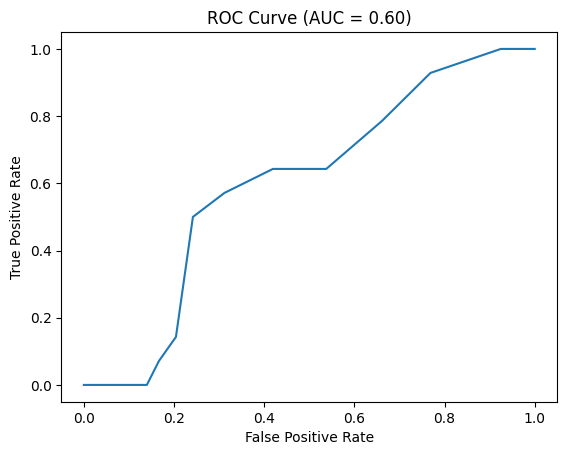

In [240]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = %0.2f)" % roc_auc)
plt.show()

In [241]:
y_prob = model.predict_proba(X_test)

In [242]:
confidence = y_prob.max(axis=1)

In [243]:
for i in range(5):
    print(
        "Prediction:", y_pred[i],
        "| Confidence:", round(confidence[i]*100, 2), "%"
    )

Prediction: 0 | Confidence: 77.0 %
Prediction: 0 | Confidence: 79.0 %
Prediction: 0 | Confidence: 95.0 %
Prediction: 0 | Confidence: 96.0 %
Prediction: 0 | Confidence: 88.0 %
